<a href="https://colab.research.google.com/github/erstuu/Pipeline-Analisis-Sentiment-Pengunjung-Villa-LSTM-Word2Vec/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

In [7]:
# Load dari file backup
df_balanced = pd.read_csv('dataset_preprocessed.csv')

# Buat ulang kolom tokens
df_balanced['tokens'] = df_balanced['review_clean'].apply(lambda x: str(x).split())

print(f'Data loaded: {df_balanced.shape}')
print(df_balanced['tokens'].head(3))

Data loaded: (7188, 6)
0             [berisik, karaoke, tidak, bersih, kamar]
1    [proses, check, in, parah, lengkap, mandi, par...
2                  [spanya, enak, kurang, luas, ruang]
Name: tokens, dtype: object


---
## Data Understanding

In [2]:
FILES = [
    'Amalia Hotel Lampung.csv',
    'Anugerah Express Hotel.csv',
    'Anugrah Hotel Sukabumi.csv',
    'Aryaduta Suite Semanggi.csv',
    'Asoka Luxury Hotel Lampung.csv',
    'Balcony Hotel Sukabumi.csv',
    'Grand Anugerah Hotel.csv',
    'Putri Duyung Ancol.csv',
    'RedDoorz Syariah near Wisata Situ Gunung Sukabumi.csv',
    'Sparks Odeon Sukabumi.csv',
    'The Acacia Hotel Jakarta.csv',
    'Grand Citihub Hotel @Kartini.csv'
]

# Threshold labeling sentimen (skala 1-10 Traveloka)
RATING_NEGATIVE_MAX = 6.9   # rating <= 6 → negatif
RATING_POSITIVE_MIN = 7.0   # rating >= 7 → positif

print(f'Total file terdaftar: {len(FILES)}')

Total file terdaftar: 12


### Load & Parse Semua File CSV

In [3]:
def parse_file(filepath):
    """
    Membaca file CSV dengan format non-standar (double-quoted rows).
    Mengembalikan DataFrame dengan kolom: username, rating, review.
    """
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    parsed_rows = []
    for line in lines[1:]:  # skip header
        line = line.strip()
        if line.startswith('"'): line = line[1:]
        if line.endswith('"'):   line = line[:-1]
        line = line.replace('""', '"')
        for row in csv.reader(StringIO(line)):
            if len(row) == 3:
                parsed_rows.append(row)

    df = pd.DataFrame(parsed_rows, columns=['username', 'rating', 'review'])

    # Validasi & konversi rating
    df['rating'] = df['rating'].str.replace(',', '.')
    invalid = df[~df['rating'].str.match(r'^\d+\.?\d*$')]
    if not invalid.empty:
        print(f'{filepath} → {len(invalid)} baris rating tidak valid, dibuang')
        df = df[df['rating'].str.match(r'^\d+\.?\d*$')]

    df['rating'] = df['rating'].astype(float)
    return df


def load_all_files(files):
    """
    Membaca semua file CSV dan menggabungkannya menjadi satu DataFrame.
    """
    all_dfs = []
    for file in files:
        df = parse_file(file)
        all_dfs.append(df)
        print(f'{file:<55} → {df.shape[0]} baris | null: {df.isnull().sum().to_dict()}')

    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f'\n📊 TOTAL GABUNGAN : {df_all.shape[0]} baris, {df_all.shape[1]} kolom')
    return df_all


df_all = load_all_files(FILES)

Amalia Hotel Lampung.csv                                → 980 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Anugerah Express Hotel.csv                              → 799 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Anugrah Hotel Sukabumi.csv                              → 2546 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Aryaduta Suite Semanggi.csv → 1 baris rating tidak valid, dibuang
Aryaduta Suite Semanggi.csv                             → 2041 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Asoka Luxury Hotel Lampung.csv → 1 baris rating tidak valid, dibuang
Asoka Luxury Hotel Lampung.csv                          → 1654 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Balcony Hotel Sukabumi.csv                              → 1449 baris | null: {'username': 0, 'rating': 0, 'review': 0}
Grand Anugerah Hotel.csv → 1 baris rating tidak valid, dibuang
Grand Anugerah Hotel.csv                                → 1397 baris | null: {'username': 

### Eksplorasi Data Awal

In [4]:
def explore_data(df):
    """
    Menampilkan informasi awal dataset: shape, tipe data, null, duplikat, statistik.
    """
    print('=== INFO DATASET ===')
    print(f'Shape   : {df.shape}')
    print(f'Kolom   : {df.columns.tolist()}')
    print()
    print('=== TIPE DATA ===')
    print(df.dtypes)
    print()
    print('=== NULL PER KOLOM ===')
    print(df.isnull().sum())
    print()
    print(f'=== DUPLIKAT ===')
    print(f'Jumlah baris duplikat: {df.duplicated().sum()}')
    print()
    print('=== STATISTIK RATING ===')
    print(df['rating'].describe())
    print()
    print('=== 5 BARIS PERTAMA ===')
    display(df.head())


explore_data(df_all)

=== INFO DATASET ===
Shape   : (19134, 3)
Kolom   : ['username', 'rating', 'review']

=== TIPE DATA ===
username     object
rating      float64
review       object
dtype: object

=== NULL PER KOLOM ===
username    0
rating      0
review      0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 0

=== STATISTIK RATING ===
count    19134.000000
mean         8.488445
std          1.352414
min          4.500000
25%          8.400000
50%          8.500000
75%          9.700000
max         10.000000
Name: rating, dtype: float64

=== 5 BARIS PERTAMA ===


,username,rating,review
0,s***o,10.0,"Pelayanan cukup baik, akses parkir ke hotel da..."
1,Diah A.,10.0,hotel di tengah kota dengan harga yang terjang...
2,Traveler Terverifikasi,10.0,"Sangat bagus, pelayanan memuaskan"
3,D***i,10.0,Di pusat kota jadi lebih gampang mau ke tujuan...
4,I***n,10.0,Sangat efektif dan ramah anak


### Visualisasi Distribusi Rating

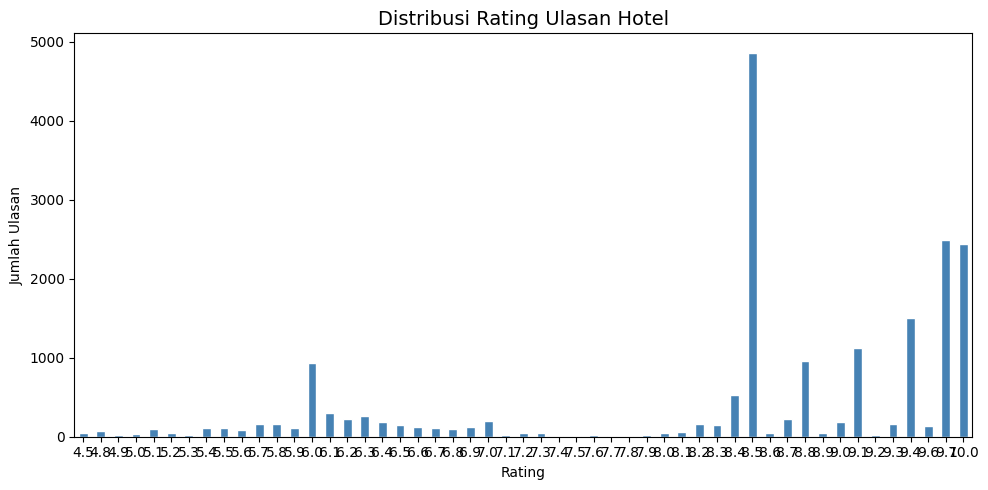


Jumlah per rating:
rating
4.5       46
4.8       74
4.9       27
5.0       33
5.1       95
5.2       50
5.3       24
5.4      114
5.5      107
5.6       83
5.7      159
5.8      156
5.9      109
6.0      929
6.1      304
6.2      230
6.3      266
6.4      180
6.5      143
6.6      129
6.7      112
6.8      102
6.9      122
7.0      200
7.1       21
7.2       49
7.3       44
7.4       10
7.5       12
7.6       21
7.7        3
7.8       15
7.9       28
8.0       41
8.1       54
8.2      166
8.3      142
8.4      527
8.5     4861
8.6       53
8.7      229
8.8      964
8.9       42
9.0      188
9.1     1128
9.2       17
9.3      160
9.4     1498
9.6      132
9.7     2495
10.0    2440
Name: count, dtype: int64


In [5]:
def plot_rating_distribution(df):
    """
    Menampilkan distribusi rating dalam bentuk bar chart.
    """
    plt.figure(figsize=(10, 5))
    df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Distribusi Rating Ulasan Hotel', fontsize=14)
    plt.xlabel('Rating')
    plt.ylabel('Jumlah Ulasan')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print('\nJumlah per rating:')
    print(df['rating'].value_counts().sort_index())


plot_rating_distribution(df_all)

---
## Pelabelan Sentimen

In [9]:
def label_sentiment(df, neg_max=6, pos_min=7):
    """
    Memberikan label sentimen berdasarkan rating.
    - rating <= neg_max → 'negative'
    - rating >= pos_min → 'positive'
    - Sisanya (netral) → dihapus
    - Review kosong    → dihapus
    """
    # Hapus review kosong
    sebelum = len(df)
    df = df[df['review'].str.strip() != '']
    df = df.dropna(subset=['review'])
    print(f'Review kosong dihapus : {sebelum - len(df)} baris')

    # Beri label
    def _label(rating):
        if rating <= neg_max:  return 'negative'
        elif rating >= pos_min: return 'positive'
        else: return None

    df = df.copy()
    df['sentiment'] = df['rating'].apply(_label)

    # Hapus netral
    netral = df['sentiment'].isnull().sum()
    df = df[df['sentiment'].notnull()].reset_index(drop=True)
    print(f'Rating netral dihapus  : {netral} baris')
    print(f'Total data final       : {len(df)} baris')

    return df


df_labeled = label_sentiment(df_all, neg_max=RATING_NEGATIVE_MAX, pos_min=RATING_POSITIVE_MIN)

Review kosong dihapus : 0 baris
Rating netral dihapus  : 0 baris
Total data final       : 19134 baris


### Cek Distribusi Sentimen (Imbalanced Check)

=== DISTRIBUSI SENTIMEN ===
  positive    :  15540 (81.2%)
  negative    :   3594 (18.8%)


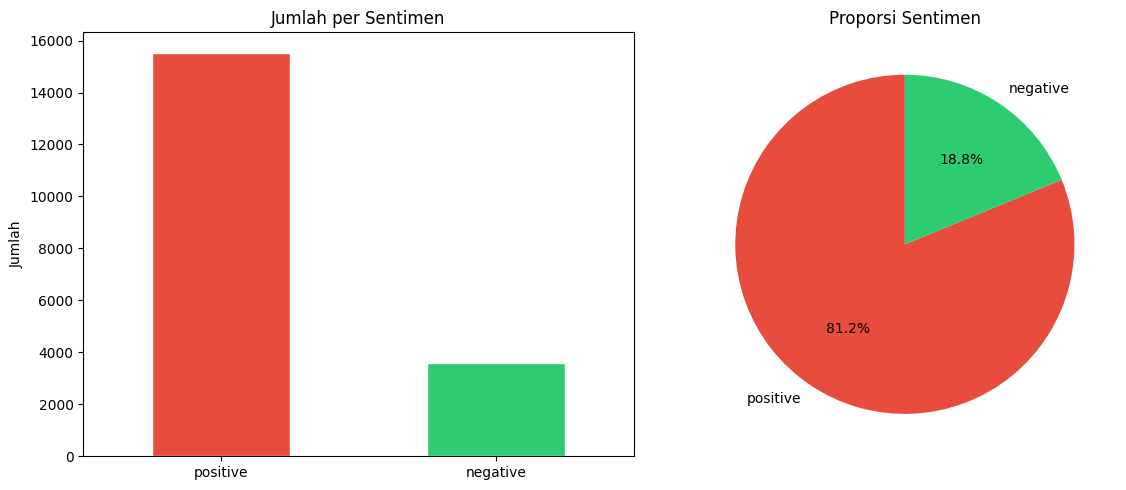


Data IMBALANCED — pertimbangkan oversampling/undersampling


In [10]:
def check_sentiment_distribution(df):
    """
    Menampilkan distribusi label sentimen dan mendeteksi imbalanced data.
    """
    counts = df['sentiment'].value_counts()
    pct    = df['sentiment'].value_counts(normalize=True) * 100

    print('=== DISTRIBUSI SENTIMEN ===')
    for label in counts.index:
        print(f'  {label:<12}: {counts[label]:>6} ({pct[label]:.1f}%)')

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
    axes[0].set_title('Jumlah per Sentimen')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Jumlah')
    axes[0].tick_params(axis='x', rotation=0)

    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=['#e74c3c', '#2ecc71'], startangle=90)
    axes[1].set_title('Proporsi Sentimen')

    plt.tight_layout()
    plt.show()

    # Deteksi imbalanced
    rasio_pos = pct.get('positive', 0)
    print()
    if rasio_pos < 40 or rasio_pos > 60:
        print('Data IMBALANCED — pertimbangkan oversampling/undersampling')
    else:
        print('Data relatif SEIMBANG')


check_sentiment_distribution(df_labeled)

### Balancing Data

Sebelum balancing → positif: 15540 | negatif: 3594
Setelah balancing  → positif: 3594 | negatif: 3594
Total data balanced: 7188


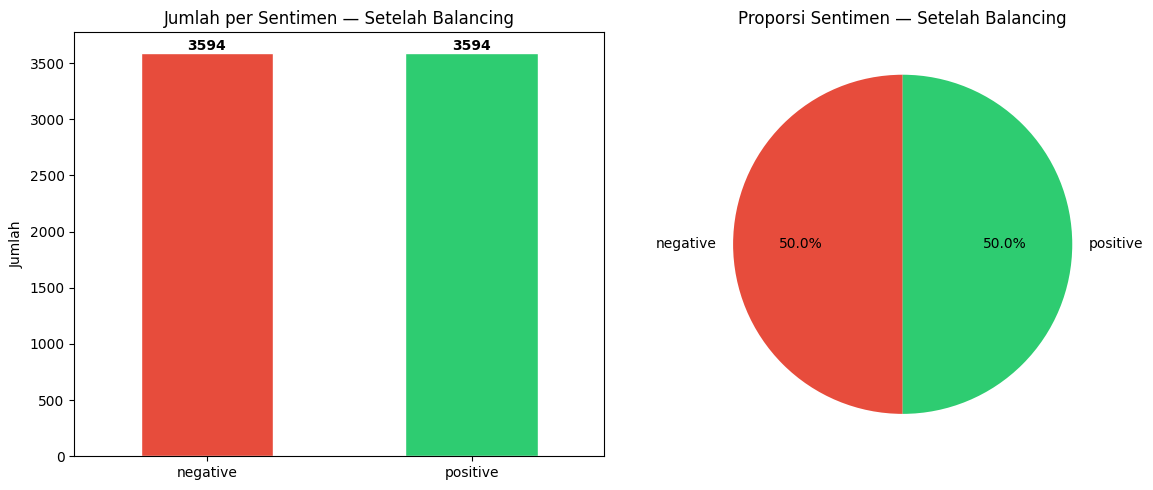

In [11]:
# Balancing Data (Undersampling)
jumlah_negatif = len(df_labeled[df_labeled['sentiment'] == 'negative'])
jumlah_positif = len(df_labeled[df_labeled['sentiment'] == 'positive'])

print(f'Sebelum balancing → positif: {jumlah_positif} | negatif: {jumlah_negatif}')

df_pos = df_labeled[df_labeled['sentiment'] == 'positive'].sample(
    n=jumlah_negatif,
    random_state=42
)
df_neg = df_labeled[df_labeled['sentiment'] == 'negative']

df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Setelah balancing  → positif: {len(df_balanced[df_balanced["sentiment"]=="positive"])} | negatif: {len(df_balanced[df_balanced["sentiment"]=="negative"])}')
print(f'Total data balanced: {len(df_balanced)}')

# Visualisasi setelah balancing
counts_after = df_balanced['sentiment'].value_counts()
pct_after    = df_balanced['sentiment'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_after.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Jumlah per Sentimen — Setelah Balancing')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts_after):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts_after, labels=counts_after.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporsi Sentimen — Setelah Balancing')

plt.tight_layout()
plt.show()

---
## Data Preparation (Preprocessing)

In [ ]:
!pip install PySastrawi
!pip install nltk
import nltk
nltk.download('stopwords')
print('✅ Library preprocessing siap')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 13.9 MB/s eta 0:00:00
✅ Library preprocessing siap


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Data Cleaning

In [ ]:
import re

def clean_text(text):
    """
    Menghapus karakter tidak relevan:
    emoji, URL, angka, simbol, karakter non-alfanumerik.
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)          # hapus URL
    text = re.sub(r'[^\w\s]', ' ', text)                 # hapus simbol & tanda baca
    text = re.sub(r'\d+', '', text)                       # hapus angka
    text = re.sub(r'[^\x00-\x7F]+', '', text)            # hapus emoji & karakter non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()              # normalisasi spasi
    return text


df_balanced['review_clean'] = df_balanced['review'].apply(clean_text)
print('Data Cleaning selesai')
print(df_balanced[['review', 'review_clean']].head(3))

Data Cleaning selesai
                                              review  \
0  Noisy dari karaoke, tidak membersihkan kamar";...   
1  Proses check-in parah, perlengkapan mandi para...   
2     Spanya enak tapi kurang luas ruangannya.";;;;;   

                                        review_clean  
0        Noisy dari karaoke tidak membersihkan kamar  
1  Proses check in parah perlengkapan mandi parah...  
2            Spanya enak tapi kurang luas ruangannya  


In [ ]:
# # Cek sample review yang mengandung kata bahasa Inggris
# import re

# def has_english_words(text):
#     # Deteksi kata yang kemungkinan bahasa Inggris (bukan Indonesia)
#     english_pattern = r'\b(good|bad|nice|clean|room|hotel|staff|service|noisy|great|best|worst|poor|excellent|comfortable|dirty|friendly|slow|fast|cheap|expensive)\b'
#     return bool(re.search(english_pattern, text.lower()))

# english_reviews = df_balanced[df_balanced['review_clean'].apply(has_english_words)]
# print(f'Review mengandung kata Inggris: {len(english_reviews)} dari {len(df_balanced)}')
# print(english_reviews['review_clean'].head(5))

Review mengandung kata Inggris: 2244 dari 7188
0           noisy dari karaoke tidak membersihkan kamar
4     stay di balcony selalu menyenangkan dengan rat...
6     hotel tua dan kurang bersih kamar bau rokok pe...
9     hotel ini bintang tetapi untuk kualitas pelaya...
11    kesan pertama yang sangat buruk pertama kali n...
Name: review_clean, dtype: object


In [ ]:
# Lihat kata Inggris apa saja yang paling sering muncul
from collections import Counter
import re

english_pattern = r'\b(good|bad|nice|clean|room|hotel|staff|service|noisy|great|best|worst|poor|excellent|comfortable|dirty|friendly|slow|fast|cheap|expensive)\b'

all_english_words = []
for review in df_balanced['review_clean']:
    words = re.findall(english_pattern, review.lower())
    all_english_words.extend(words)

word_freq = Counter(all_english_words)
print('Kata Inggris paling sering muncul:')
for word, count in word_freq.most_common(20):
    print(f'  {word:<15}: {count}')

Kata Inggris paling sering muncul:
  hotel          : 2493
  room           : 319
  staff          : 181
  service        : 167
  good           : 98
  bad            : 51
  best           : 31
  nice           : 24
  friendly       : 23
  great          : 19
  clean          : 16
  slow           : 9
  excellent      : 8
  fast           : 7
  dirty          : 5
  worst          : 4
  comfortable    : 3
  poor           : 2
  noisy          : 1
  expensive      : 1


### Case Folding

In [ ]:
def case_folding(text):
    """Mengubah teks menjadi huruf kecil (lowercase)."""
    return text.lower()


df_balanced['review_clean'] = df_balanced['review_clean'].apply(case_folding)
print(df_balanced['review_clean'].head(3))

0          noisy dari karaoke tidak membersihkan kamar
1    proses check in parah perlengkapan mandi parah...
2              spanya enak tapi kurang luas ruangannya
Name: review_clean, dtype: object


### Normalisasi Kata Slang

In [ ]:
# Kamus normalisasi kata tidak baku → baku
# Tambahkan kata sesuai kebutuhan dataset kamu
SLANG_DICT = {
    'gak'  : 'tidak', 'ga'    : 'tidak', 'nggak': 'tidak',
    'ngga' : 'tidak', 'enggak': 'tidak', 'tdk'  : 'tidak',
    'yg'   : 'yang',  'dgn'   : 'dengan','utk'  : 'untuk',
    'hrs'  : 'harus', 'sdh'   : 'sudah', 'blm'  : 'belum',
    'krn'  : 'karena','jd'    : 'jadi',  'sm'   : 'sama',
    'tp'   : 'tapi',  'tapi'  : 'tetapi','jg'   : 'juga',
    'bgt'  : 'banget','bngt'  : 'banget','bgs'  : 'bagus',
    'ok'   : 'oke',   'mantap': 'mantap','keren': 'keren',
    'jelek': 'jelek', 'brsih' : 'bersih','nyaman': 'nyaman',
    # Kata bahasa Inggris bermakna sentimen
    'good'       : 'bagus',   'bad'        : 'buruk',
    'best'       : 'terbaik', 'nice'       : 'bagus',
    'friendly'   : 'ramah',   'great'      : 'bagus',
    'clean'      : 'bersih',  'slow'       : 'lambat',
    'excellent'  : 'luar biasa', 'fast'    : 'cepat',
    'dirty'      : 'kotor',   'worst'      : 'terburuk',
    'comfortable': 'nyaman',  'poor'       : 'buruk',
    'noisy'      : 'berisik', 'expensive'  : 'mahal',
}

# Kata bahasa Inggris umum yang tidak bermakna sentimen → masuk stopwords nanti
STOPWORDS_TAMBAHAN = {'hotel', 'room', 'staff', 'service'}

def normalize_slang(text, slang_dict=SLANG_DICT):
    """Mengganti kata tidak baku dengan kata baku."""
    words = text.split()
    return ' '.join([slang_dict.get(w, w) for w in words])


df_balanced['review_clean'] = df_balanced['review_clean'].apply(normalize_slang)
print(df_balanced['review_clean'].head(3))

0        berisik dari karaoke tidak membersihkan kamar
1    proses check in parah perlengkapan mandi parah...
2            spanya enak tetapi kurang luas ruangannya
Name: review_clean, dtype: object


### Stopword Removal

In [ ]:
from nltk.corpus import stopwords

KATA_PENTING = {'tidak', 'kurang', 'bukan', 'belum', 'jangan', 'tanpa'}

STOPWORDS_ID = set(stopwords.words('indonesian')) | STOPWORDS_TAMBAHAN
STOPWORDS_ID = STOPWORDS_ID - KATA_PENTING  # hapus dari stoplist

def remove_stopwords(text, stopwords=STOPWORDS_ID):
    """Menghapus kata hubung yang tidak bermakna sentimen."""
    words = text.split()
    return ' '.join([w for w in words if w not in stopwords])


df_balanced['review_clean'] = df_balanced['review_clean'].apply(remove_stopwords)
print(df_balanced['review_clean'].head(3))

0             berisik karaoke tidak membersihkan kamar
1    proses check in parah perlengkapan mandi parah...
2                   spanya enak kurang luas ruangannya
Name: review_clean, dtype: object


### Stemming (Sastrawi)

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    """Mengubah kata berimbuhan menjadi kata dasar."""
    return stemmer.stem(text)


# Catatan: proses ini cukup lambat untuk data besar
# Gunakan tqdm untuk melihat progress
from tqdm import tqdm
tqdm.pandas()

df_balanced['review_clean'] = df_balanced['review_clean'].progress_apply(stem_text)
print(df_balanced['review_clean'].head(3))

100%|██████████| 7188/7188 [00:01<00:00, 6503.21it/s]

0                   berisik karaoke tidak bersih kamar
1    proses check in parah lengkap mandi parah tida...
2                        spanya enak kurang luas ruang
Name: review_clean, dtype: object


### Tokenisasi

In [ ]:
def tokenize(text):
    """Memecah kalimat menjadi list token kata."""
    return text.split()


df_balanced['tokens'] = df_balanced['review_clean'].apply(tokenize)
print(df_balanced['tokens'].head(3))

0             [berisik, karaoke, tidak, bersih, kamar]
1    [proses, check, in, parah, lengkap, mandi, par...
2                  [spanya, enak, kurang, luas, ruang]
Name: tokens, dtype: object


### Simpan Dataset yang Sudah Diproses

In [ ]:
# Simpan ke CSV
df_balanced[['username', 'rating', 'review', 'review_clean', 'sentiment']].to_csv(
    'dataset_preprocessed.csv', index=False
)
print('Dataset tersimpan: dataset_preprocessed.csv')
print(f'Shape final: {df_balanced.shape}')
display(df_balanced[['review', 'review_clean', 'sentiment']].head())

Dataset tersimpan: dataset_preprocessed.csv
Shape final: (7188, 6)


,review,review_clean,sentiment
0,"Noisy dari karaoke, tidak membersihkan kamar"";...",berisik karaoke tidak bersih kamar,negative
1,"Proses check-in parah, perlengkapan mandi para...",proses check in parah lengkap mandi parah tida...,negative
2,"Spanya enak tapi kurang luas ruangannya."";;;;;",spanya enak kurang luas ruang,negative
3,"Lama pelayanannya, membiarkan customer terlant...",layan biar customer lantar,negative
4,Stay di Balcony selalu menyenangkan. Dengan ra...,stay balcony senang rate minimal fasilitas mak...,positive


---
## Word Embedding (Word2Vec) & Splitting Data

In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec

def train_word2vec(tokens, vector_size=100, window=5, min_count=2, epochs=10):
    """
    Melatih model Word2Vec dari token hasil preprocessing.
    """
    model = Word2Vec(
        sentences   = tokens,
        vector_size = vector_size,
        window      = window,
        min_count   = min_count,
        workers     = 4,
        epochs      = epochs
    )
    print(f'Word2Vec selesai — vocab size: {len(model.wv)}')
    return model


w2v_model = train_word2vec(df_balanced['tokens'].tolist())
w2v_model.save('word2vec_hotel.model')
print('Model Word2Vec tersimpan: word2vec_hotel.model')

✅ Word2Vec selesai — vocab size: 3363
Model Word2Vec tersimpan: word2vec_hotel.model


### Konversi Teks ke Sekuens Angka

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

MAX_WORDS  = 10000   # ukuran vocabulary
MAX_LEN    = 100     # panjang maksimum sekuens

def prepare_sequences(df, max_words=MAX_WORDS, max_len=MAX_LEN):
    """
    Mengubah teks menjadi sekuens angka yang siap masuk ke LSTM.
    """

    df = df.copy()
    df['review_clean'] = df['review_clean'].fillna('').astype(str)

    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['review_clean'])

    sequences = tokenizer.texts_to_sequences(df['review_clean'])
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # Encode label: positive=1, negative=0
    le = LabelEncoder()
    y  = le.fit_transform(df['sentiment'])   # negative=0, positive=1

    print(f'X shape: {X.shape}')
    print(f'y shape: {y.shape}')
    print(f'   Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

    return X, y, tokenizer, le


X, y, tokenizer, label_encoder = prepare_sequences(df_balanced)

✅ X shape: (7188, 100)
✅ y shape: (7188,)
   Label mapping: {'negative': np.int64(0), 'positive': np.int64(1)}


### Split Data Train & Test (80:20)

In [ ]:
def split_data(X, y, test_size=0.2, random_state=42):
    """
    Membagi data menjadi training set (80%) dan testing set (20%).
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = test_size,
        random_state = random_state,
        stratify     = y   # menjaga proporsi label tetap seimbang
    )
    print(f'✅ Data Training : {X_train.shape[0]} ({100-test_size*100:.0f}%)')
    print(f'✅ Data Testing  : {X_test.shape[0]} ({test_size*100:.0f}%)')
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(X, y)

✅ Data Training : 5750 (80%)
✅ Data Testing  : 1438 (20%)


---
## Modeling (LSTM)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 100  # harus sama dengan vector_size Word2Vec

def build_embedding_matrix(word2vec_model, tokenizer, vocab_size, embedding_dim=EMBEDDING_DIM):
    """Membuat embedding matrix dari Word2Vec untuk dipakai di Embedding layer."""
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, idx in tokenizer.word_index.items():
        if idx < vocab_size:
            if word in word2vec_model.wv:
                embedding_matrix[idx] = word2vec_model.wv[word]
    covered = np.count_nonzero(embedding_matrix.any(axis=1))
    print(f'✅ Kata tercoverage Word2Vec: {covered}/{vocab_size} ({covered/vocab_size*100:.1f}%)')
    return embedding_matrix

def build_lstm_model(vocab_size, embedding_matrix, embedding_dim=EMBEDDING_DIM, max_len=MAX_LEN):
    """Membangun arsitektur LSTM dengan bobot Word2Vec."""
    model = Sequential([
        Embedding(
            input_dim  = vocab_size,
            output_dim = embedding_dim,
            weights    = [embedding_matrix],  # ← bobot dari Word2Vec
            trainable  = False                # ← embedding tidak ikut dilatih
        ),
        LSTM(128, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # output biner: 0=negatif, 1=positif
    ])

    model.compile(
        optimizer = Adam(learning_rate=0.0005),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

    model.summary()
    return model


# Jalankan
vocab_size       = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_matrix = build_embedding_matrix(w2v_model, tokenizer, vocab_size)
model            = build_lstm_model(vocab_size, embedding_matrix)

✅ Kata tercoverage Word2Vec: 3363/6787 (49.6%)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       678,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 678,700 (2.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 678,700 (2.59 MB)

### Training Model

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=20, batch_size=64):
    """
    Melatih model LSTM dengan EarlyStopping untuk mencegah overfitting.
    """
    early_stop = EarlyStopping(
        monitor   = 'val_loss',
        patience  = 3,
        restore_best_weights = True
    )

    history = model.fit(
        X_train, y_train,
        epochs          = epochs,
        batch_size      = batch_size,
        validation_data = (X_test, y_test),
        callbacks       = [early_stop],
        verbose         = 1
    )
    return history


history = train_model(model, X_train, y_train, X_test, y_test)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5190 - loss: 0.6855 - val_accuracy: 0.7969 - val_loss: 0.5026
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7992 - loss: 0.5205 - val_accuracy: 0.8025 - val_loss: 0.4684
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8049 - loss: 0.4848 - val_accuracy: 0.8122 - val_loss: 0.4383
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8208 - loss: 0.4414 - val_accuracy: 0.8199 - val_loss: 0.4380
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8492 - loss: 0.4095 - val_accuracy: 0.8255 - val_loss: 0.4044
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8424 - loss: 0.3890 - val_accuracy: 0.8366 - val_loss: 0.4192
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8414 - loss: 0.3897 - val_accuracy: 0.8366 - val_loss: 0.3939
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8589 - loss: 0.3667 - val_accuracy: 0.8373 - v

### 5c. Visualisasi Training History

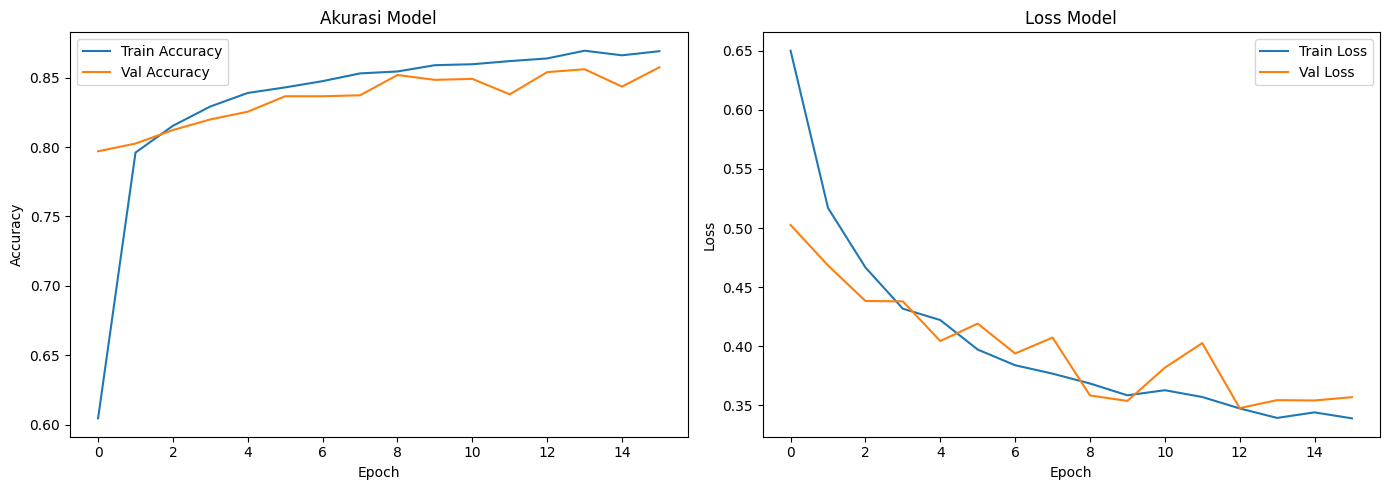

In [ ]:
def plot_training_history(history):
    """
    Menampilkan grafik akurasi dan loss selama proses training.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Akurasi
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Akurasi Model')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Loss Model')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)

---
## Evaluation

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== HASIL EVALUASI ===
Accuracy : 0.8540

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.89      0.86       719
    positive       0.88      0.82      0.85       719

    accuracy                           0.85      1438
   macro avg       0.86      0.85      0.85      1438
weighted avg       0.86      0.85      0.85      1438



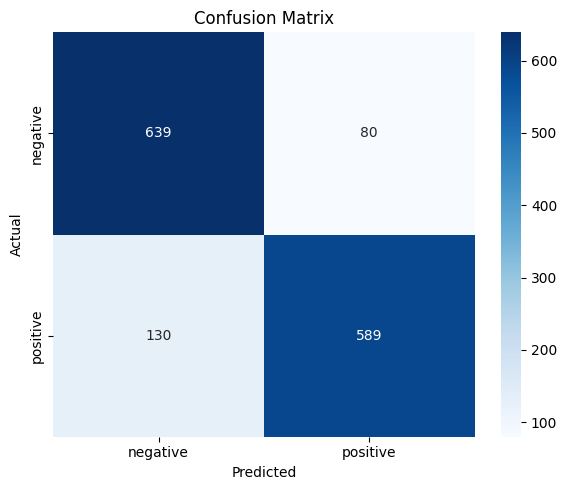

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_test, y_test):
    """
    Mengevaluasi performa model menggunakan data uji.
    Menampilkan: Accuracy, Precision, Recall, F1-Score, Confusion Matrix.
    """
    y_pred_prob = model.predict(X_test)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

    print('=== HASIL EVALUASI ===')
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'positive'],
                yticklabels=['negative', 'positive'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return y_pred


y_pred = evaluate_model(model, X_test, y_test)

---
## Menyimpan Model

In [ ]:
model.save('lstm_sentiment_model.h5')
print('✅ Model LSTM tersimpan: lstm_sentiment_model.h5')